# Broadband qubit spectroscopy

In [15]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.experiments.cal06_qubit_spectroscopy_full_bandwidth import BroadbandQubitSpectroscopy

## Run parameters

In [16]:
HARDWARE_CONFIG = Path(r"..\config\hw_config.json")
DEVICE_CONFIG = Path(r"..\config\dut_config.json")
FLUX_CONFIG = Path(r"..\config\flux_config.json")  # If use None, it will not change the value already in the hardware
OUTPUT_DIR = Path("data")

QUBITS = ["q0"]
FREQUENCY_CENTER = 5.4e9
FREQUENCY_WIDTH = 1.6e9
FREQUENCY_POINTS = 1001
MAXIMUM_BRANCH_WIDTH = 800e6
REPETITIONS = 10
DRIVE_AMPLITUDE = 0.02
DRIVE_DURATION = 1e-6

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
RESTORE_DRIVE_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = Path(r"..\config\dut_config_upd.json")  # Use None if param persisting is not required


## Hardware and experiment

In [17]:
hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = BroadbandQubitSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

## Branch plan

In [18]:
branches = experiment.plan_branches(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
)
for branch in branches:
    print(
        f"Branch {branch.index + 1}: "
        f"{branch.start / 1e9:.6f}-{branch.stop / 1e9:.6f} GHz, "
        f"LO {branch.lo_frequency / 1e9:.6f} GHz, "
        f"{branch.points} points"
    )

Branch 1: 4.600000-5.400000 GHz, LO 5.000000 GHz, 501 points
Branch 2: 5.401600-6.200000 GHz, LO 5.800800 GHz, 500 points


## Measurement

In [19]:

dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
    repetitions=REPETITIONS,
    drive_amplitude=DRIVE_AMPLITUDE,
    drive_duration=DRIVE_DURATION,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    restore_drive_lo_frequency=RESTORE_DRIVE_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

<xarray.Dataset> Size: 32kB
Dimensions:           (acq_index_S21_q0: 1001)
Coordinates:
    frequency_q0      (acq_index_S21_q0) float64 8kB 4.6e+09 ... 6.2e+09
  * acq_index_S21_q0  (acq_index_S21_q0) int64 8kB 0 1 2 3 ... 997 998 999 1000
Data variables:
    S21_q0            (acq_index_S21_q0) complex128 16kB (-0.0014450948238372...
Attributes:
    tuid:     20260811-155416-160-c011b7

## Optional: Simulated data

In [6]:
dataset = experiment.simulated_data(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    qubit_frequency=5.444e9,
    linewidth=10e6,
    phase_offset=0.0,
    noise=0.002,
    seed=42,
)

## Analysis

In [7]:
results = experiment.analysis()
for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: f01 = {result.frequency / 1e9:.9f} GHz, "
            f"linewidth = {result.linewidth / 1e6:.3f} MHz"
        )
    else:
        print(f"{qubit}: qubit-spectroscopy fit failed")

q0: f01 = 5.443997755 GHz, linewidth = 10.011 MHz


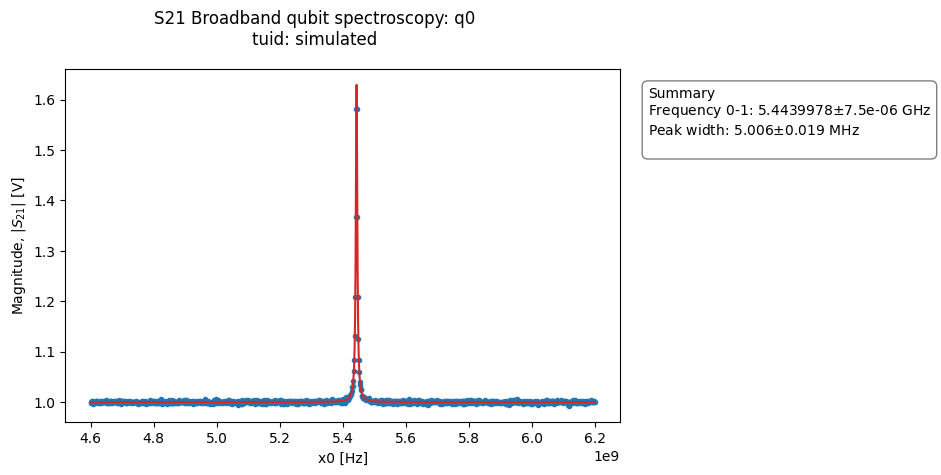

In [8]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

A successful fitted `f01` is written only to the new file selected by `SAVE_FITTED_DEVICE`. The input device file remains unchanged.

In [14]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to ..\config\dut_config_upd.json
